## Import packages

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [7]:
data=pd.read_excel("KWTRP_Questionnaire_Final_Corrected_267.xlsx")
data.head()


,Gender,Age_Category,Education_Level,Department,Employment_Level,Years_at_KWTRP,Conscientiousness_1,Conscientiousness_2,Conscientiousness_3,Conscientiousness_4,...,PQI_Positive_Feedback,PQI_Recognized_Performance,Productivity_1,Productivity_2,Productivity_3,Productivity_4,PerformanceQuality_1,PerformanceQuality_2,PerformanceQuality_3,PerformanceQuality_4
0,Male,36–45,Masters,Research,Operational,4–6 years,Neutral,Agree,Neutral,Strongly Agree,...,NaN,Selected,Agree,Agree,Agree,Agree,Agree,Agree,Strongly Agree,Agree
1,Female,26–35,PhD,HR & Administration,Supervisory,1–3 years,Neutral,Neutral,Neutral,Agree,...,Selected,Selected,Agree,Neutral,Strongly Agree,Agree,Neutral,Agree,Agree,Agree
2,Female,26–35,Masters,HR & Administration,Supervisory,4–6 years,Agree,Disagree,Neutral,Agree,...,Selected,Selected,Agree,Agree,Agree,Strongly Agree,Agree,Agree,Agree,Neutral
3,Female,36–45,Diploma,Clinical Trials,Supervisory,Less than 1 year,Neutral,Agree,Agree,Agree,...,Selected,NaN,Strongly Agree,Neutral,Neutral,Strongly Agree,Agree,Agree,Agree,Agree
4,Male,36–45,Degree,ICT,Management,Less than 1 year,Agree,Agree,Neutral,Agree,...,NaN,NaN,Agree,Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Neutral,Agree


## Response Rate

## Cronbach's Alpha

## Demographic Analysis 

### Gender

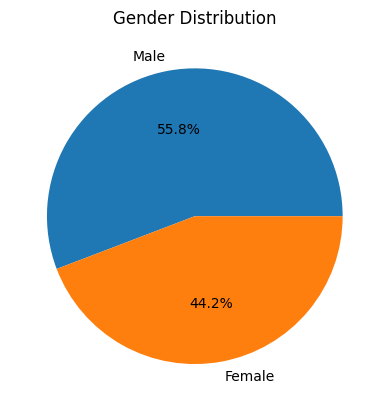

In [ ]:
data['Gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

### Age Analysis 

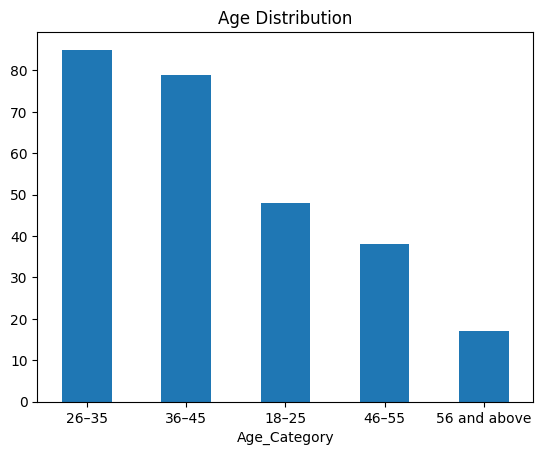

In [10]:
data['Age_Category'].value_counts().plot.bar()
plt.title("Age Distribution")
plt.xticks(rotation=0)
plt.show()

### Level of education 

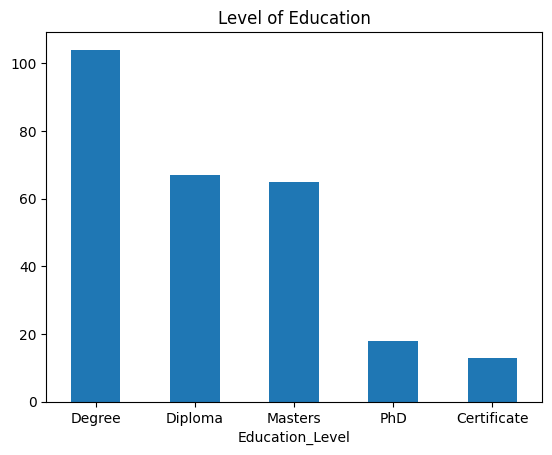

In [14]:
data['Education_Level'].value_counts().plot.bar()
plt.title("Level of Education")
plt.xticks(rotation=0)
plt.show()

### Department 

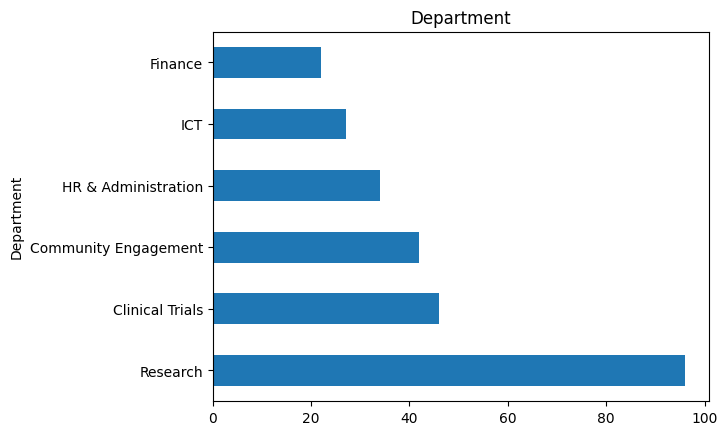

In [18]:
data['Department'].value_counts().plot.barh()
plt.title("Department")
plt.xticks(rotation=0)
plt.show()

### Employment_Level

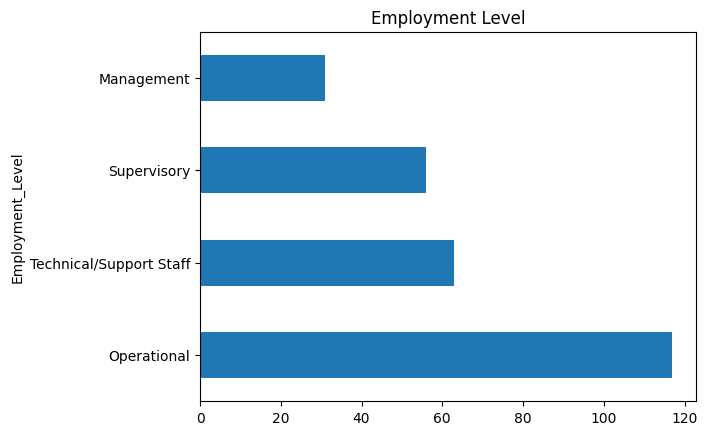

In [22]:
data['Employment_Level'].value_counts().plot.barh()
plt.title("Employment Level")
plt.xticks(rotation=0)
plt.show()


### Years at KWTRP

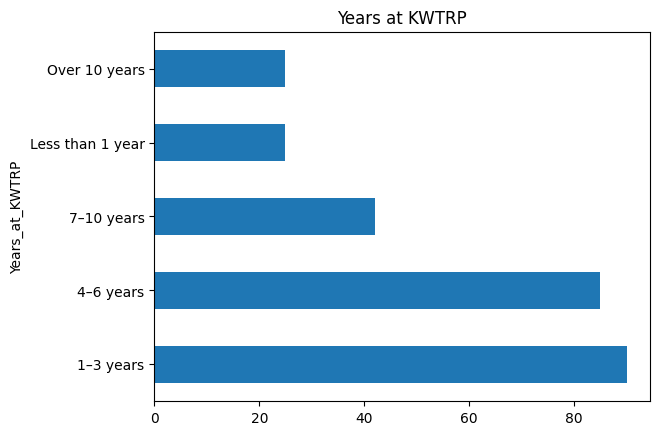

In [24]:
data['Years_at_KWTRP'].value_counts().plot.barh()
plt.title("Years at KWTRP")
plt.xticks(rotation=0)
plt.show()

## Descriptive analysis

### PERSONAL ATTRIBUTES AND EMPLOYEE PERFORMANCE

In [27]:
# Descriptive analysis for Conscientiousness items


# Select columns
cols = [
    'Conscientiousness_1',
    'Conscientiousness_2',
    'Conscientiousness_3',
    'Conscientiousness_4',
    'Conscientiousness_5'
]

# Rename columns with questionnaire statements
statements = {
    'Conscientiousness_1': '1. I complete assigned tasks on time.',
    'Conscientiousness_2': '2. I pay close attention to detail in my work.',
    'Conscientiousness_3': '3. I follow institutional procedures carefully.',
    'Conscientiousness_4': '4. I remain disciplined even when workload is high.',
    'Conscientiousness_5': '5. I take responsibility for correcting mistakes in my work.'
}

# Likert order
likert_order = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Create descriptive table
results = []

for col in cols:
    
    percentages = (
        data[col]
        .value_counts(normalize=True)
        .reindex(likert_order, fill_value=0)
        * 100
    ).round(1)
    
    results.append({
        'Statement': statements[col],
        'SD%': percentages['Strongly Disagree'],
        'D%': percentages['Disagree'],
        'N%': percentages['Neutral'],
        'A%': percentages['Agree'],
        'SA%': percentages['Strongly Agree']
    })

# Convert to dataframe
desc_table = pd.DataFrame(results)

# Display
#print(desc_table)

# Optional: prettier display
desc_table

,Statement,SD%,D%,N%,A%,SA%
0,1. I complete assigned tasks on time.,0.0,3.7,27.3,47.9,21.0
1,2. I pay close attention to detail in my work.,0.4,3.4,27.7,46.8,21.7
2,3. I follow institutional procedures carefully.,0.7,5.6,28.5,47.6,17.6
3,4. I remain disciplined even when workload is ...,0.0,3.7,30.0,47.9,18.4
4,5. I take responsibility for correcting mistak...,0.0,3.0,32.2,47.9,16.9


In [33]:
# Descriptive Analysis for Adaptability Variables


# Define columns and statements
adaptability_cols = {
    'Adaptability_1': 'I adjust quickly to changes in work procedures.',
    'Adaptability_2': 'I adapt effectively to new technologies.',
    'Adaptability_3': 'I remain productive during organizational changes.',
    'Adaptability_4': 'I respond positively to new work demands.'
}

# Likert response order
likert_order = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Create empty list to store results
results = []

# Loop through each column
for col, statement in adaptability_cols.items():
    
    # Calculate percentages
    percentages = (
        data[col]
        .value_counts(normalize=True)
        .reindex(likert_order, fill_value=0) * 100
    ).round(1)
    
    # Append results
    results.append({
        'Statement': statement,
        'SD%': percentages['Strongly Disagree'],
        'D%': percentages['Disagree'],
        'N%': percentages['Neutral'],
        'A%': percentages['Agree'],
        'SA%': percentages['Strongly Agree']
    })

# Create descriptive table
adaptability_descriptive = pd.DataFrame(results)

# Display table
adaptability_descriptive

,Statement,SD%,D%,N%,A%,SA%
0,I adjust quickly to changes in work procedures.,0.0,3.7,28.5,48.3,19.5
1,I adapt effectively to new technologies.,0.4,7.5,31.5,43.4,17.2
2,I remain productive during organizational chan...,0.4,6.4,31.1,40.8,21.3
3,I respond positively to new work demands.,0.4,4.1,31.1,41.9,22.5


In [37]:
# Descriptive analysis for Self-Efficacy variables


# Mapping column names to questionnaire statements
statements = {
    'SelfEfficacy_1': 'I am confident in my ability to meet performance targets.',
    'SelfEfficacy_2': 'I believe I can overcome challenges in my work.',
    'SelfEfficacy_3': 'I believe I can meet the performance standards required in my role.',
    'SelfEfficacy_4': 'I am capable of solving complex work-related problems.'
}

# Likert scale order
scale_order = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Create empty list to store results
results = []

# Loop through each variable
for col, statement in statements.items():
    
    # Calculate percentages
    percentages = (
        data[col]
        .value_counts(normalize=True)
        .reindex(scale_order, fill_value=0)
        * 100
    ).round(1)
    
    # Append results
    results.append({
        'Statement': statement,
        'SD%': percentages['Strongly Disagree'],
        'D%': percentages['Disagree'],
        'N%': percentages['Neutral'],
        'A%': percentages['Agree'],
        'SA%': percentages['Strongly Agree']
    })

# Convert to DataFrame
selfefficacy_desc = pd.DataFrame(results)

# Display table
selfefficacy_desc

,Statement,SD%,D%,N%,A%,SA%
0,I am confident in my ability to meet performan...,0.0,6.0,31.1,46.8,16.1
1,I believe I can overcome challenges in my work.,0.0,5.6,27.7,48.3,18.4
2,I believe I can meet the performance standards...,0.4,8.2,33.7,41.9,15.7
3,I am capable of solving complex work-related p...,0.4,3.0,31.1,47.9,17.6


In [ ]:
# Descriptive analysis for  Emotional Intelligence variables

# Emotional Intelligence columns
ei_columns = {
    'EmotionalIntelligence_1': 'I remain calm under pressure.',
    'EmotionalIntelligence_2': 'I remain composed under pressure.',
    'EmotionalIntelligence_3': 'I handle workplace conflicts with professionalism and empathy.',
    'EmotionalIntelligence_4': 'I understand the emotions of my colleagues.',
    'EmotionalIntelligence_5': 'I resolve interpersonal conflicts professionally.'
}

# Likert scale order
likert_order = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Short names
short_names = {
    'Strongly Disagree': 'SD%',
    'Disagree': 'D%',
    'Neutral': 'N%',
    'Agree': 'A%',
    'Strongly Agree': 'SA%'
}

# Empty list to store results
results = []

# Loop through each column
for col, statement in ei_columns.items():
    
    # Percentage calculation
    percentages = (
        data[col]
        .value_counts(normalize=True)
        .reindex(likert_order, fill_value=0)
        * 100
    ).round(1)
    
    # Create row
    row = {'Statement': statement}
    
    for scale in likert_order:
        row[short_names[scale]] = percentages[scale]
    
    results.append(row)

# Create descriptive table
ei_descriptive = pd.DataFrame(results)

# Display table
#print(ei_descriptive)

# Optional prettier display
#ei_descriptive.style.hide(axis='index')

ei_descriptive

,Statement,SD%,D%,N%,A%,SA%
0,I remain calm under pressure.,0.7,5.2,30.0,46.1,18.0
1,I remain composed under pressure.,0.0,3.7,27.7,52.1,16.5
2,I handle workplace conflicts with professional...,0.0,6.0,34.5,43.4,16.1
3,I understand the emotions of my colleagues.,0.0,5.2,29.6,47.9,17.2
4,I resolve interpersonal conflicts professionally.,0.4,8.2,30.3,42.3,18.7


### JOB RELATED FACTORS AND EMPLOYEE PERFORMANCE

In [41]:
# Leadership Quality Descriptive Analysis

# Leadership Quality columns
leadership_cols = {
    "LeadershipQuality_1": "Leadership provides clear direction for my work.",
    "LeadershipQuality_2": "My supervisor supports me in achieving performance targets.",
    "LeadershipQuality_3": "Leadership decisions are fair and transparent.",
    "LeadershipQuality_4": "Leaders encourage innovation.",
    "LeadershipQuality_5": "Leaders encourage initiative."
}

# Likert scale order
scale_order = [
    "Strongly Disagree",
    "Disagree",
    "Neutral",
    "Agree",
    "Strongly Agree"
]

# Short column names
short_names = {
    "Strongly Disagree": "SD%",
    "Disagree": "D%",
    "Neutral": "N%",
    "Agree": "A%",
    "Strongly Agree": "SA%"
}

# Create empty list
results = []

# Loop through each column
for col, statement in leadership_cols.items():
    
    # Calculate percentages
    percentages = (
        data[col]
        .value_counts(normalize=True)
        .reindex(scale_order, fill_value=0)
        * 100
    ).round(1)
    
    # Create row
    row = {"Statement": statement}
    
    for scale in scale_order:
        row[short_names[scale]] = percentages[scale]
    
    results.append(row)

# Convert to DataFrame
leadership_descriptive = pd.DataFrame(results)

# Display results
leadership_descriptive

,Statement,SD%,D%,N%,A%,SA%
0,Leadership provides clear direction for my work.,0.0,2.6,30.0,45.7,21.7
1,My supervisor supports me in achieving perform...,0.0,5.6,30.0,44.9,19.5
2,Leadership decisions are fair and transparent.,0.0,7.1,34.1,40.1,18.7
3,Leaders encourage innovation.,0.0,6.7,30.3,40.1,22.8
4,Leaders encourage initiative.,1.1,5.6,31.1,42.7,19.5


In [42]:
# Descriptive analysis for Task Structure variables


# Select Task Structure columns
task_cols = [
    'TaskStructure_1',
    'TaskStructure_2',
    'TaskStructure_3',
    'TaskStructure_4'
]

# Rename statements
statements = {
    'TaskStructure_1': '1. My job responsibilities are clearly defined.',
    'TaskStructure_2': '2. I understand what is expected of me in my role.',
    'TaskStructure_3': '3. My tasks are well organized and structured.',
    'TaskStructure_4': '4. I have adequately autonomy to complete my tasks.'
}

# Likert scale order
likert_order = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Create empty list to store results
results = []

# Loop through each variable
for col in task_cols:
    
    # Calculate percentages
    percentages = (
        data[col]
        .value_counts(normalize=True)
        .reindex(likert_order, fill_value=0)
        * 100
    ).round(1)
    
    # Append results
    results.append({
        'Statement': statements[col],
        'SD%': percentages['Strongly Disagree'],
        'D%': percentages['Disagree'],
        'N%': percentages['Neutral'],
        'A%': percentages['Agree'],
        'SA%': percentages['Strongly Agree']
    })

# Create final table
task_structure_desc = pd.DataFrame(results)

# Display table
task_structure_desc

,Statement,SD%,D%,N%,A%,SA%
0,1. My job responsibilities are clearly defined.,0.4,6.0,35.2,39.7,18.7
1,2. I understand what is expected of me in my r...,0.4,3.4,28.8,49.1,18.4
2,3. My tasks are well organized and structured.,0.7,5.2,30.0,41.2,22.8
3,4. I have adequately autonomy to complete my t...,0.7,5.2,28.8,44.9,20.2


In [43]:
# Descriptive Analysis for Supervision and Feedback Variables


# Select columns
cols = [
    'SupervisionFeedback_1',
    'SupervisionFeedback_2',
    'SupervisionFeedback_3',
    'SupervisionFeedback_4'
]

# Rename columns with questionnaire statements
labels = {
    'SupervisionFeedback_1': 'I receive regular feedback on my performance.',
    'SupervisionFeedback_2': 'Performance evaluations are fair and objective.',
    'SupervisionFeedback_3': 'My supervisor provides constructive guidance.',
    'SupervisionFeedback_4': 'Feedback helps me improve my performance.'
}

# Likert scale order
scale_order = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Short names for output
short_names = {
    'Strongly Disagree': 'SD%',
    'Disagree': 'D%',
    'Neutral': 'N%',
    'Agree': 'A%',
    'Strongly Agree': 'SA%'
}

# Empty list to store results
results = []

# Loop through each column
for col in cols:
    
    percentages = (
        data[col]
        .value_counts(normalize=True)
        .reindex(scale_order, fill_value=0)
        * 100
    ).round(1)
    
    row = {'Statement': labels[col]}
    
    for scale in scale_order:
        row[short_names[scale]] = percentages[scale]
    
    results.append(row)

# Create descriptive table
desc_table = pd.DataFrame(results)

# Display table
print(desc_table)

                                         Statement  SD%   D%    N%    A%   SA%
0    I receive regular feedback on my performance.  0.0  4.5  28.8  44.6  22.1
1  Performance evaluations are fair and objective.  0.0  4.5  27.7  52.1  15.7
2    My supervisor provides constructive guidance.  0.0  6.4  27.3  44.6  21.7
3        Feedback helps me improve my performance.  0.0  5.2  29.6  46.8  18.4


In [47]:
# Descriptive Analysis for Training and Development Variables

training_cols = {
    'TrainingDevelopment_1': 'I receive adequate training for my role.',
    'TrainingDevelopment_2': 'Professional development opportunities are available.',
    'TrainingDevelopment_3': 'Training enhances my job performance.',
    'TrainingDevelopment_4': 'I am encouraged to upgrade my skills.'
}

# Likert scale order
likert_order = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Abbreviations
short_names = {
    'Strongly Disagree': 'SD%',
    'Disagree': 'D%',
    'Neutral': 'N%',
    'Agree': 'A%',
    'Strongly Agree': 'SA%'
}

# Create empty list
results = []

# Loop through each variable
for col, statement in training_cols.items():
    
    # Percentage distribution
    percentages = (
        data[col]
        .value_counts(normalize=True)
        .reindex(likert_order, fill_value=0)
        * 100
    ).round(1)
    
    # Store results
    row = {'Statement': statement}
    
    for scale in likert_order:
        row[short_names[scale]] = percentages[scale]
    
    results.append(row)

# Create dataframe
descriptive_table = pd.DataFrame(results)

# Display results
descriptive_table

,Statement,SD%,D%,N%,A%,SA%
0,I receive adequate training for my role.,0.4,3.7,31.1,47.6,17.2
1,Professional development opportunities are ava...,0.0,4.5,32.2,46.1,17.2
2,Training enhances my job performance.,0.0,4.5,30.7,45.7,19.1
3,I am encouraged to upgrade my skills.,0.0,3.7,34.5,42.7,19.1


In [45]:
# Workload Balance Descriptive Analysis


# Rename columns with actual statements
workload_cols = {
    'WorkloadBalance_1': '1. My workload is manageable.',
    'WorkloadBalance_2': '2. I can complete my tasks within allocated timelines.',
    'WorkloadBalance_3': '3. Work pressure does not compromise my performance quality.',
    'WorkloadBalance_4': '4. Tasks are distributed fairly within my unit.'
}

# Create empty list to store results
results = []

# Likert order
likert_order = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Loop through each variable
for col, statement in workload_cols.items():
    
    # Get percentage distribution
    percentages = (
        data[col]
        .value_counts(normalize=True)
        .reindex(likert_order, fill_value=0)
        * 100
    ).round(1)
    
    # Append results
    results.append({
        'Statement': statement,
        'SD%': percentages['Strongly Disagree'],
        'D%': percentages['Disagree'],
        'N%': percentages['Neutral'],
        'A%': percentages['Agree'],
        'SA%': percentages['Strongly Agree']
    })

# Convert to DataFrame
workload_descriptive = pd.DataFrame(results)

# Display table
workload_descriptive

,Statement,SD%,D%,N%,A%,SA%
0,1. My workload is manageable.,1.5,13.1,44.6,29.2,11.6
1,2. I can complete my tasks within allocated ti...,1.9,13.1,39.3,37.8,7.9
2,3. Work pressure does not compromise my perfor...,1.9,13.5,39.0,34.1,11.6
3,4. Tasks are distributed fairly within my unit.,2.6,11.6,39.3,33.3,13.1


### EXTERNAL FACTORS AND EMPLOYEE PERFORMANCE

In [50]:
# Descriptive Analysis for Donor Funding Variables



# Rename columns using questionnaire statements
donor_cols = {
    'DonorFunding_1': 'Funding cycles are predictable',
    'DonorFunding_2': 'Funding stability supports consistent work performance',
    'DonorFunding_3': 'Changes in donor funding affect my job continuity',
    'DonorFunding_4': 'Project based contracts influence my performance stability'
}

# Likert scale order
likert_order = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Create empty list for results
results = []

# Loop through each donor funding variable
for col, statement in donor_cols.items():
    
    # Get percentage distribution
    percentages = (
        data[col]
        .value_counts(normalize=True)
        .reindex(likert_order, fill_value=0)
        * 100
    ).round(1)
    
    # Append results
    results.append({
        'Statement': statement,
        'SD%': percentages['Strongly Disagree'],
        'D%': percentages['Disagree'],
        'N%': percentages['Neutral'],
        'A%': percentages['Agree'],
        'SA%': percentages['Strongly Agree']
    })

# Create final dataframe
donor_descriptive = pd.DataFrame(results)

# Display results
donor_descriptive

,Statement,SD%,D%,N%,A%,SA%
0,Funding cycles are predictable,0.4,6.0,29.6,47.9,16.1
1,Funding stability supports consistent work per...,0.4,4.1,29.6,48.7,17.2
2,Changes in donor funding affect my job continuity,5.6,24.7,36.0,27.0,6.7
3,Project based contracts influence my performan...,6.4,21.0,43.8,22.8,6.0


In [51]:
# Descriptive Analysis for Regulatory and Policy Environment


# Columns to analyze
columns = {
    'RegulatoryPolicy_1': 'Institutional policies are clear and consistent.',
    'RegulatoryPolicy_2': 'National research regulations supports my work.',
    'RegulatoryPolicy_3': 'Policy changes disrupt workflow efficiency',
    'RegulatoryPolicy_4': 'Compliance requirements affect task timelines.'
}

# Likert categories
categories = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Create empty list
results = []

# Loop through each column
for col, statement in columns.items():
    
    total = len(data[col])
    
    counts = data[col].value_counts()
    
    row = {
        'Statement': statement,
        'SD%': round((counts.get('Strongly Disagree', 0) / total) * 100, 1),
        'D%': round((counts.get('Disagree', 0) / total) * 100, 1),
        'N%': round((counts.get('Neutral', 0) / total) * 100, 1),
        'A%': round((counts.get('Agree', 0) / total) * 100, 1),
        'SA%': round((counts.get('Strongly Agree', 0) / total) * 100, 1)
    }
    
    results.append(row)

# Convert to dataframe
descriptive_table = pd.DataFrame(results)

# Display table
descriptive_table

,Statement,SD%,D%,N%,A%,SA%
0,Institutional policies are clear and consistent.,0.0,5.6,30.7,45.3,18.4
1,National research regulations supports my work.,0.0,4.5,29.2,42.7,23.6
2,Policy changes disrupt workflow efficiency,6.4,22.8,41.2,25.8,3.7
3,Compliance requirements affect task timelines.,0.7,6.4,30.0,42.3,20.6


In [52]:
# Descriptive Analysis for Technological Factors


# Technology columns
technology_cols = {
    'Technology_1': 'Available technology supports my productivity',
    'Technology_2': 'I receive adequate support when systems fail',
    'Technology_3': 'I am trained to adapt to technological changes',
    'Technology_4': 'Technological systems improve work efficiency'
}

# Likert order
likert_order = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Short names for table columns
short_names = {
    'Strongly Disagree': 'SD%',
    'Disagree': 'D%',
    'Neutral': 'N%',
    'Agree': 'A%',
    'Strongly Agree': 'SA%'
}

# Create empty list
results = []

# Loop through each technology variable
for col, statement in technology_cols.items():
    
    # Calculate percentages
    percentages = (
        data[col]
        .value_counts(normalize=True)
        .reindex(likert_order, fill_value=0) * 100
    ).round(1)
    
    # Create row
    row = {
        'Statement': statement,
        'SD%': percentages['Strongly Disagree'],
        'D%': percentages['Disagree'],
        'N%': percentages['Neutral'],
        'A%': percentages['Agree'],
        'SA%': percentages['Strongly Agree']
    }
    
    results.append(row)

# Convert to DataFrame
technology_descriptive = pd.DataFrame(results)

# Display table
technology_descriptive

,Statement,SD%,D%,N%,A%,SA%
0,Available technology supports my productivity,0.0,1.5,22.1,49.8,26.6
1,I receive adequate support when systems fail,0.0,2.2,19.5,53.6,24.7
2,I am trained to adapt to technological changes,0.0,1.5,24.0,50.2,24.3
3,Technological systems improve work efficiency,0.0,2.6,20.2,52.4,24.7


 ### EXTERNAL FACTORS

                        Frequency  Percentage
Primary_Work_Output                          
Reports                        59        22.1
Research Samples               53        19.9
Community Sessions             46        17.2
System Support Tickets         43        16.1
Patient Cases                  38        14.2
Data Entries                   28        10.5


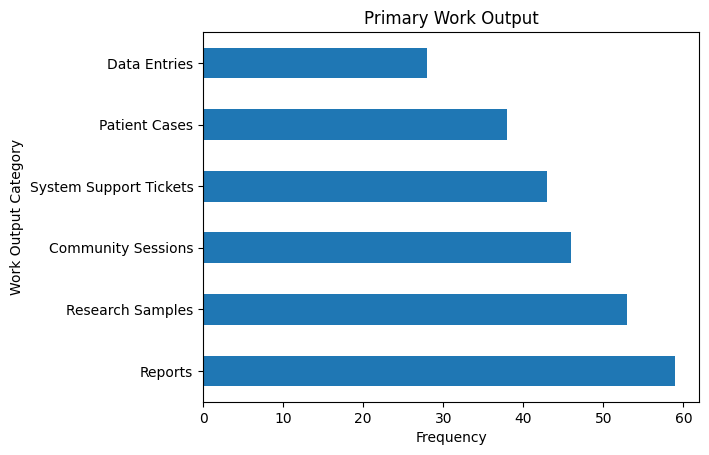

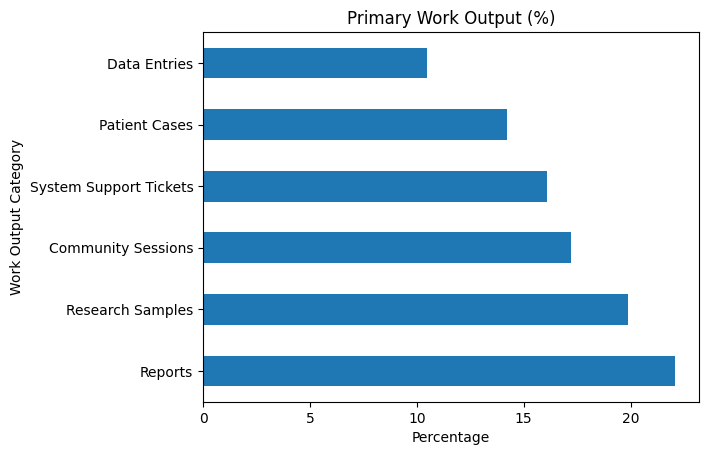

In [71]:
# Frequency distribution for Primary Work Output
#10 a) 

# Frequency and Percentage Analysis

output_analysis = pd.DataFrame({
    'Frequency': data['Primary_Work_Output'].value_counts(),
    'Percentage': round(
        data['Primary_Work_Output'].value_counts(normalize=True) * 100, 1
    )
})

print(output_analysis)

data['Primary_Work_Output'].value_counts().plot.barh()

plt.title("Primary Work Output")
plt.xlabel("Frequency")
plt.ylabel("Work Output Category")

plt.show()

# Percentage distribution

(
    data['Primary_Work_Output']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .plot.barh()
)

plt.title("Primary Work Output (%)")
plt.xlabel("Percentage")
plt.ylabel("Work Output Category")

plt.show()

count    267.000000
mean      55.426966
std       21.350400
min       20.000000
25%       39.000000
50%       54.000000
75%       74.000000
max      100.000000
Name: Expected_Monthly_Output, dtype: float64


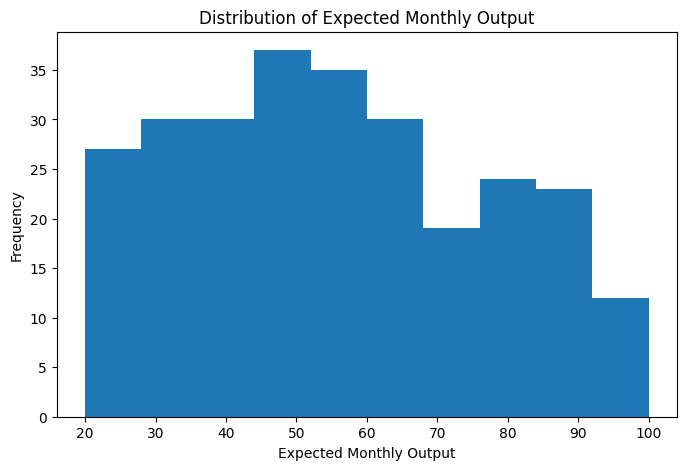

In [68]:
# Descriptive statistics

print(data['Expected_Monthly_Output'].describe())

# Histogram

plt.figure(figsize=(8,5))

plt.hist(data['Expected_Monthly_Output'], bins=10)

plt.title("Distribution of Expected Monthly Output")
plt.xlabel("Expected Monthly Output")
plt.ylabel("Frequency")

plt.show()

count    267.000000
mean      55.426966
std       21.350400
min       20.000000
25%       39.000000
50%       54.000000
75%       74.000000
max      100.000000
Name: Expected_Monthly_Output, dtype: float64


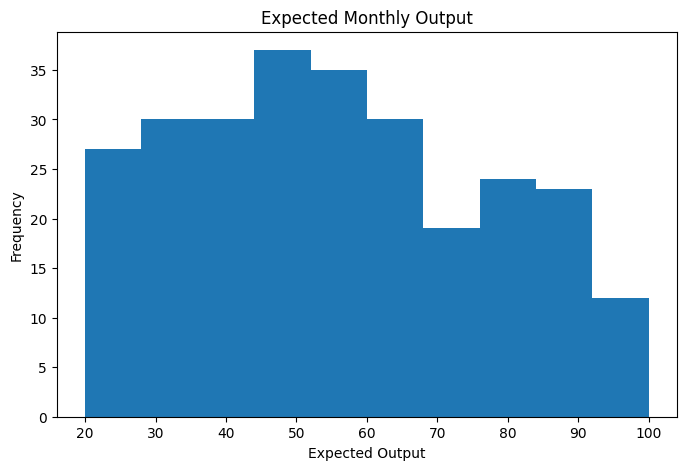

In [74]:
# Descriptive statistics

print(data['Expected_Monthly_Output'].describe())

# Histogram

plt.figure(figsize=(8,5))

plt.hist(data['Expected_Monthly_Output'], bins=10)

plt.title("Expected Monthly Output")
plt.xlabel("Expected Output")
plt.ylabel("Frequency")

plt.show()

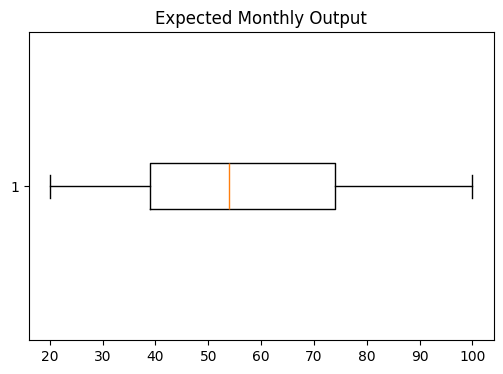

In [75]:
# Boxplot

plt.figure(figsize=(6,4))

plt.boxplot(data['Expected_Monthly_Output'], vert=False)

plt.title("Expected Monthly Output")

plt.show()

In [55]:
# Descriptive Analysis for Productivity Items

# Rename columns using questionnaire statements
productivity_cols = {
    'Productivity_1': '1. I consistently meet my assigned performance targets.',
    'Productivity_2': '2. I complete my work within the expected timelines.',
    'Productivity_3': '3. My output level meets institutional expectations.',
    'Productivity_4': '4. I maintain high productivity throughout project cycles.'
}

# Select and rename
prod_data = data[list(productivity_cols.keys())].rename(columns=productivity_cols)

# Likert scale order
likert_order = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Create descriptive table
results = pd.DataFrame()

for col in prod_data.columns:
    
    percentages = (
        prod_data[col]
        .value_counts(normalize=True)
        .reindex(likert_order, fill_value=0)
        * 100
    ).round(1)
    
    results.loc[col, 'SD%'] = percentages['Strongly Disagree']
    results.loc[col, 'D%'] = percentages['Disagree']
    results.loc[col, 'N%'] = percentages['Neutral']
    results.loc[col, 'A%'] = percentages['Agree']
    results.loc[col, 'SA%'] = percentages['Strongly Agree']

# Reset index for clean display
results = results.reset_index().rename(columns={'index': 'Statement'})

# Display
#print(results)

# Optional prettier display
results.style.format({
    'SD%': '{:.1f}%',
    'D%': '{:.1f}%',
    'N%': '{:.1f}%',
    'A%': '{:.1f}%',
    'SA%': '{:.1f}%'
})

,Statement,SD%,D%,N%,A%,SA%
0,1. I consistently meet my assigned performance targets.,0.0%,0.4%,16.5%,53.2%,30.0%
1,2. I complete my work within the expected timelines.,0.0%,1.9%,19.9%,49.8%,28.5%
2,3. My output level meets institutional expectations.,0.0%,3.4%,13.9%,54.3%,28.5%
3,4. I maintain high productivity throughout project cycles.,0.0%,1.5%,18.0%,49.4%,31.1%


In [57]:
# Descriptive Analysis for Performance Quality Variables

# Columns and their statements
columns = {
    'PerformanceQuality_1': 'My work meets the expected quality standards',
    'PerformanceQuality_2': 'I adhere to ethical and professional standards in my tasks',
    'PerformanceQuality_3': 'I contribute effectively to teamwork and knowledge sharing',
    'PerformanceQuality_4': 'My supervisor is satisfied with my work quality'
}

# Likert order
likert_order = [
    'Strongly Disagree',
    'Disagree',
    'Neutral',
    'Agree',
    'Strongly Agree'
]

# Empty list to store results
results = []

# Loop through each column
for col, statement in columns.items():
    
    # Calculate percentages
    percentages = (
        data[col]
        .value_counts(normalize=True)
        .reindex(likert_order, fill_value=0) * 100
    ).round(1)
    
    # Append results
    results.append({
        'Statement': statement,
        'SD%': percentages['Strongly Disagree'],
        'D%': percentages['Disagree'],
        'N%': percentages['Neutral'],
        'A%': percentages['Agree'],
        'SA%': percentages['Strongly Agree']
    })

# Create final descriptive table
descriptive_table = pd.DataFrame(results)

# Display table
#print(descriptive_table)

descriptive_table

# Optional: export to Excel
# descriptive_table.to_excel("Performance_Quality_Descriptive_Analysis.xlsx", index=False)

,Statement,SD%,D%,N%,A%,SA%
0,My work meets the expected quality standards,0.0,0.4,17.6,48.7,33.3
1,I adhere to ethical and professional standards...,0.0,2.2,18.4,49.8,29.6
2,I contribute effectively to teamwork and knowl...,0.0,0.4,20.2,50.6,28.8
3,My supervisor is satisfied with my work quality,0.0,0.4,16.9,55.1,27.7


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 74 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Gender                      267 non-null    object
 1   Age_Category                267 non-null    object
 2   Education_Level             267 non-null    object
 3   Department                  267 non-null    object
 4   Employment_Level            267 non-null    object
 5   Years_at_KWTRP              267 non-null    object
 6   Conscientiousness_1         267 non-null    object
 7   Conscientiousness_2         267 non-null    object
 8   Conscientiousness_3         267 non-null    object
 9   Conscientiousness_4         267 non-null    object
 10  Conscientiousness_5         267 non-null    object
 11  Adaptability_1              267 non-null    object
 12  Adaptability_2              267 non-null    object
 13  Adaptability_3              267 non-null    object